In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
from scipy.sparse import hstack
import warnings

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11

In [2]:
df = pd.read_csv("../data/processed/tickets_clean.csv")
df_en = df[df["language"] == "en"].copy().reset_index(drop=True)

In [3]:
print("shape:", df_en.shape)
print("priority 분포:")
print(df_en["priority"].value_counts())

shape: (16335, 16)
priority 분포:
priority
medium    6616
high      6345
low       3374
Name: count, dtype: int64


In [6]:
# 텍스트 피처
df_en["text"] = df_en["subject"].fillna("") + " " + df_en["body"].fillna("")
df_en["text"] = df_en["text"].str.lower().str.strip()

# queue 원핫인코딩
queue_dummies = pd.get_dummies(df_en["queue"], prefix="queue")

X_text = df_en["text"]
y      = df_en["priority"]

X_train_txt, X_test_txt, y_train, y_test, idx_train, idx_test = train_test_split(
    X_text, y, df_en.index,
    test_size=0.2, random_state=42, stratify=y
)

# TF-IDF
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=3, sublinear_tf=True)
X_train_tfidf = tfidf.fit_transform(X_train_txt)
X_test_tfidf  = tfidf.transform(X_test_txt)

from scipy.sparse import csr_matrix

q_train = csr_matrix(queue_dummies.loc[idx_train].values)
q_test  = csr_matrix(queue_dummies.loc[idx_test].values)

X_train = hstack([X_train_tfidf, q_train])
X_test  = hstack([X_test_tfidf,  q_test])

print("최종 Feature shape (train):", X_train.shape)

최종 Feature shape (train): (13068, 5010)


In [8]:
# Logistic Regression

lr = LogisticRegression(max_iter=1000, C=1.0, random_state=42, class_weight="balanced")
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Logistic Regression")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(classification_report(y_test, y_pred_lr))

Logistic Regression
Accuracy: 0.5856
              precision    recall  f1-score   support

        high       0.66      0.64      0.65      1269
         low       0.46      0.62      0.53       675
      medium       0.60      0.52      0.56      1323

    accuracy                           0.59      3267
   macro avg       0.58      0.59      0.58      3267
weighted avg       0.60      0.59      0.59      3267



In [13]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(classification_report(y_test, y_pred_rf))

Random Forest
Accuracy: 0.7591
              precision    recall  f1-score   support

        high       0.78      0.81      0.79      1269
         low       0.91      0.52      0.66       675
      medium       0.70      0.84      0.76      1323

    accuracy                           0.76      3267
   macro avg       0.80      0.72      0.74      3267
weighted avg       0.78      0.76      0.75      3267



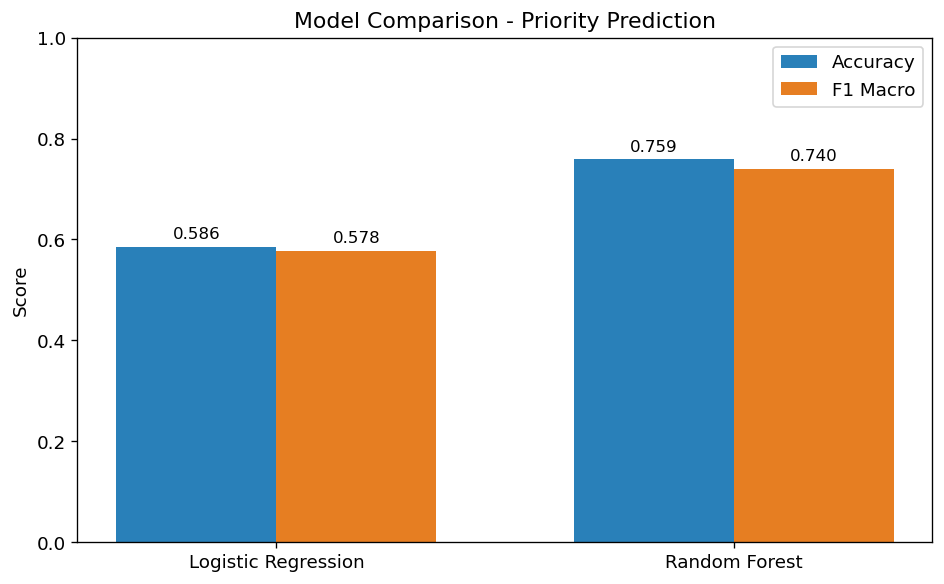

In [14]:
from sklearn.metrics import f1_score

models     = ["Logistic Regression", "Random Forest"]
accuracies = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_rf)
]
f1_macros  = [
    f1_score(y_test, y_pred_lr, average="macro"),
    f1_score(y_test, y_pred_rf, average="macro")
]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, accuracies, width, label="Accuracy", color="#2980b9")
bars2 = ax.bar(x + width/2, f1_macros,  width, label="F1 Macro", color="#e67e22")

ax.set_title("Model Comparison - Priority Prediction")
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.legend()

for bar in bars1 + bars2:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{bar.get_height():.3f}",
        ha="center", va="bottom", fontsize=10
    )

plt.tight_layout()
plt.savefig("../outputs/figures/05_model_comparison.png")
plt.show()

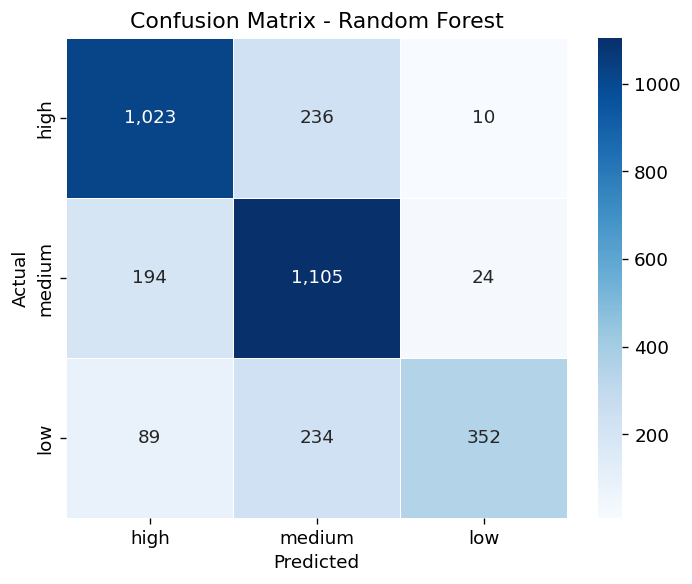

In [16]:
priority_order = ["high", "medium", "low"]

best_pred = y_pred_lr if accuracy_score(y_test, y_pred_lr) >= accuracy_score(y_test, y_pred_rf) else y_pred_rf
best_name = "Logistic Regression" if accuracy_score(y_test, y_pred_lr) >= accuracy_score(y_test, y_pred_rf) else "Random Forest"

cm = confusion_matrix(y_test, best_pred, labels=priority_order)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt=",",
    cmap="Blues",
    xticklabels=priority_order,
    yticklabels=priority_order,
    linewidths=0.5,
    ax=ax
)
ax.set_title(f"Confusion Matrix - {best_name}")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig("../outputs/figures/05_confusion_matrix.png")
plt.show()